<a href="https://colab.research.google.com/github/Bhanvi08/ML-Predictive-Modeling-Suite/blob/main/CALIFORNIA_HOUSING_PRICE_PREDICTION_by_Bhanvi_Singh_Chauhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First few rows of the data ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

1. Linear Regression RMSE: 71098.699820

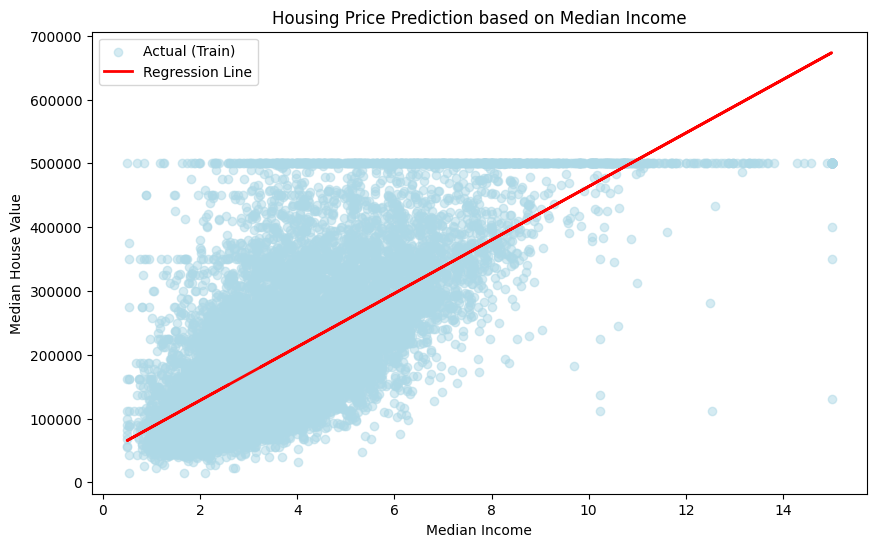


Assignment 1 is complete!


In [ ]:
# Name: Bhanvi Singh Chauhan
# Imbalance Learning - CALIFORNIA HOUSING PRICE PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. LOAD THE DATA (Using the URL since the file upload was failing)
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print("--- First few rows of the data ---")
print(df.head())

# 2. HANDLE MISSING VALUES
# Fill the missing values in total_bedrooms with the mean of that column
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

# 3. ENCODE CATEGORICAL DATA
# Convert 'ocean_proximity' to numerical data
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

# Extract input (X) and output (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 4. SPLIT THE DATASET (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. STANDARDIZE DATA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. PERFORM LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print(f"\n1. Linear Regression RMSE: {lr_rmse}")

# 7. PERFORM DECISION TREE REGRESSION
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_predictions = dt_model.predict(X_test_scaled)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
print(f"2. Decision Tree RMSE: {dt_rmse}")

# 8. PERFORM RANDOM FOREST REGRESSION
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"3. Random Forest RMSE: {rf_rmse}")

# 9. BONUS EXERCISE: Linear Regression with one independent variable (median_income)
# Extract just the median_income column (median_income is at index 7)
X_train_income = X_train[['median_income']]
X_test_income = X_test[['median_income']]

# Perform Linear Regression for one variable
simple_lr = LinearRegression()
simple_lr.fit(X_train_income, y_train)
income_pred_test = simple_lr.predict(X_test_income)

# Plotting the regression chart
plt.figure(figsize=(10,6))
plt.scatter(X_train_income, y_train, color='lightblue', alpha=0.5, label='Actual (Train)')
plt.plot(X_train_income, simple_lr.predict(X_train_income), color='red', linewidth=2, label='Regression Line')
plt.title('Housing Price Prediction based on Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

print("\nAssignment 1 is complete!")